# Merge

This Jupyter notebook has been created to compare different features with several open source Python librairies for rasters management.

This notebook will particularly focus on merging a raster object.

The following librairies will be considered :
- rasterio
- rioxarray
- odc-geo
- geoutils

In [37]:
import numpy as np

import rasterio
from rasterio.merge import merge
from rasterio.plot import show

import rioxarray
from rioxarray.merge import merge_arrays

import odc.geo.xr

import geoutils as gu
from geoutils.raster import merge_rasters

import matplotlib.pyplot as plt

import dask

## Merge

Merge feature is implemented in rasterio, rioxarray and geoutils librairies, but not in odc-geo.

Merging is the process of combining multiple rasters into a single, continuous image. It can be useful to work on a uniform image for analysis, but also simplifies processing, visualization, storage etc.

In this notebook, we will show how to merge into one image the island of Sardigna that has been separated in two different rasters.

In [38]:
#path to the raster objects
rast1_path = "../data/sard_1.tif"
rast2_path = "../data/sard_2.tif"

### • rasterio

In [39]:
rasters = [rast1_path, rast2_path]

src_rasters_to_mosaic = [rasterio.open(r) for r in rasters]

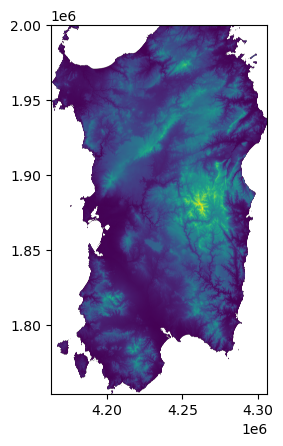

<Axes: >

In [40]:
show(src_rasters_to_mosaic[0])

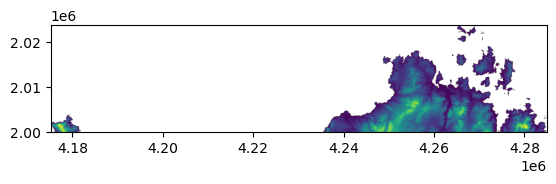

<Axes: >

In [41]:
show(src_rasters_to_mosaic[1])

In [55]:
rasterio_merged = merge(src_rasters_to_mosaic)

In [56]:
rasterio_merged

(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],
       shape=(1, 10785, 5761), dtype=float32),
 Affine(25.0, 0.0, 4162400.0,
        0.0, -25.0, 2023750.0))

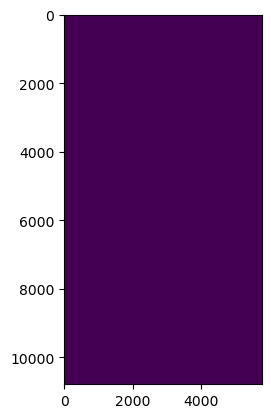

<Axes: >

In [67]:
show(rasterio_merged[0])

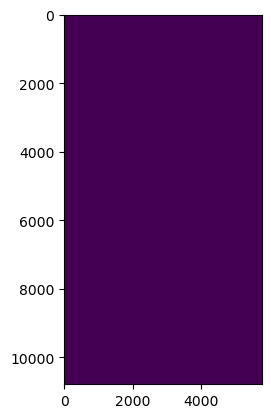

<Axes: >

In [59]:
show(rasterio_merged[0])

==TO BE COMPLETED==

### • rioxarray

In [27]:
rasters = [rast1_path, rast2_path]

rasters_to_mosaic = [rioxarray.open_rasterio(r) for r in rasters]

We can plot our two rasters that we would like to merge :

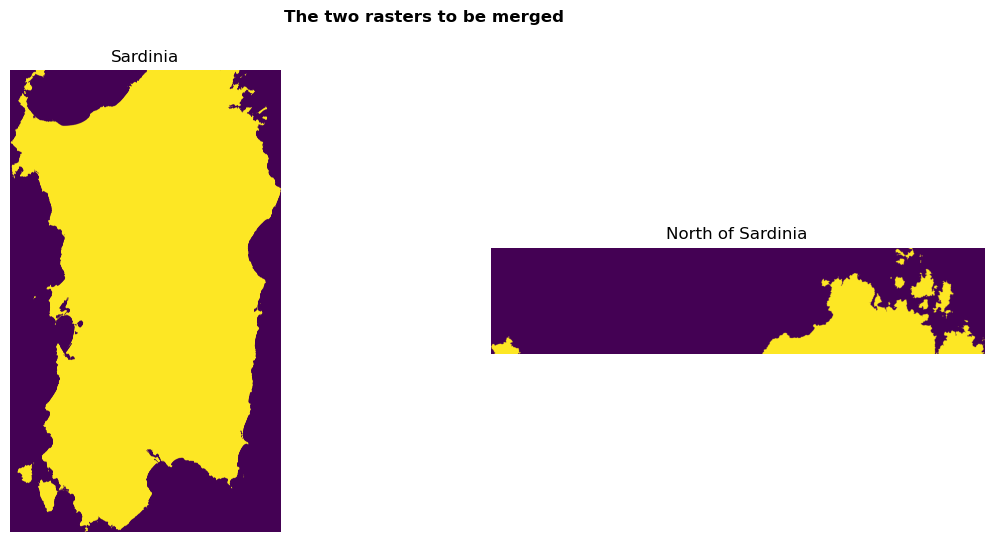

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle("The two rasters to be merged", fontweight="bold")

#sardinia
axes[0].imshow(rasters_to_mosaic[0].sel(band=1))
axes[0].set_title("Sardinia")
axes[0].axis("off")

#north sardinia
axes[1].imshow(rasters_to_mosaic[1].sel(band=1))
axes[1].set_title("North of Sardinia")
axes[1].axis("off")

plt.show()

We will use the *merge_arrays()* from rioxarray : https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray.merge.merge_arrays

We give the list of our opened rasters to be merged :

In [29]:
rxr_merged = merge_arrays(rasters_to_mosaic)

We can plot the result :

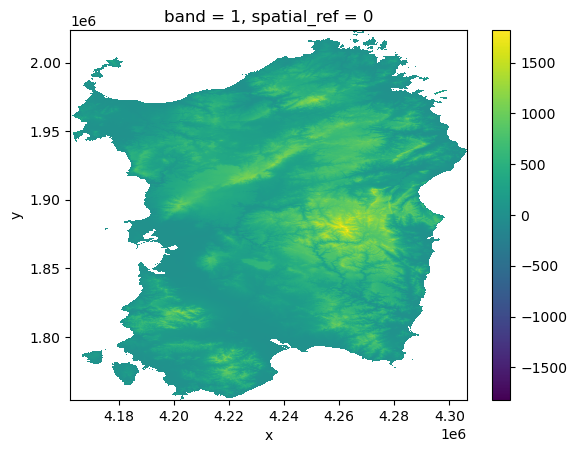

In [30]:
rxr_merged.where(rxr_merged!=rxr_merged.rio.nodata).plot(cmap="viridis")

### • geoutils

With geoutils, we can simply use the *merge_rasters()* function : https://geoutils.readthedocs.io/en/stable/gen_modules/geoutils.raster.merge_rasters.html

In [31]:
rasters_to_mosaic = [gu.Raster(r) for r in rasters]

In [32]:
rasters_to_mosaic[0]

Raster(
  data=not_loaded; shape on disk (1, 9835, 5761); will load (9835, 5761)
  transform=| 25.00, 0.00, 4162400.00|
            | 0.00,-25.00, 2000000.00|
            | 0.00, 0.00, 1.00|
  crs=IGNF:ETRS89LAEA
  nodata=-3.4028234663852886e+38)

In [33]:
rasters_to_mosaic[1]

Raster(
  data=not_loaded; shape on disk (1, 950, 4389); will load (950, 4389)
  transform=| 25.00, 0.00, 4175200.00|
            | 0.00,-25.00, 2023750.00|
            | 0.00, 0.00, 1.00|
  crs=IGNF:ETRS89LAEA
  nodata=-3.4028234663852886e+38)

Here we call the function by giving our rasters as an argument :

In [34]:
gu_merged = merge_rasters(rasters_to_mosaic)

100%|██████████| 2/2 [00:02<00:00,  1.11s/it]


And finally we can plot our merged raster :

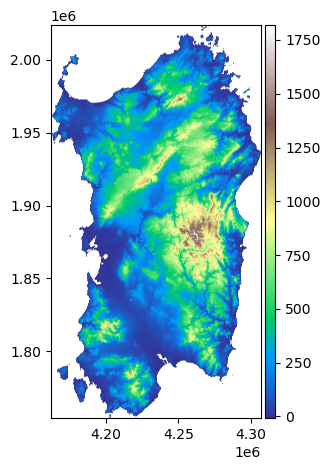

In [35]:
gu_merged.plot(cmap="terrain")